In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
# set once — new tensors land on MPS without device= every call
if torch.backends.mps.is_available():
    torch.set_default_device("mps")
torch.set_printoptions(sci_mode=False)

In [2]:
names = lambda : open("names.txt").read().splitlines()

In [3]:
stoi = {s:i+1 for i, s in enumerate(sorted(set(''.join(names()))))} | {'.':0,}
itos = {i:s for s, i in stoi.items()}


In [84]:
N = torch.zeros((27,27), dtype=int)

In [85]:
for name in names():
    name = ['.']+list(name)+['.']
    for s1, s2 in zip(name, name[1:]):
        N[stoi[s1], stoi[s2]] += 1

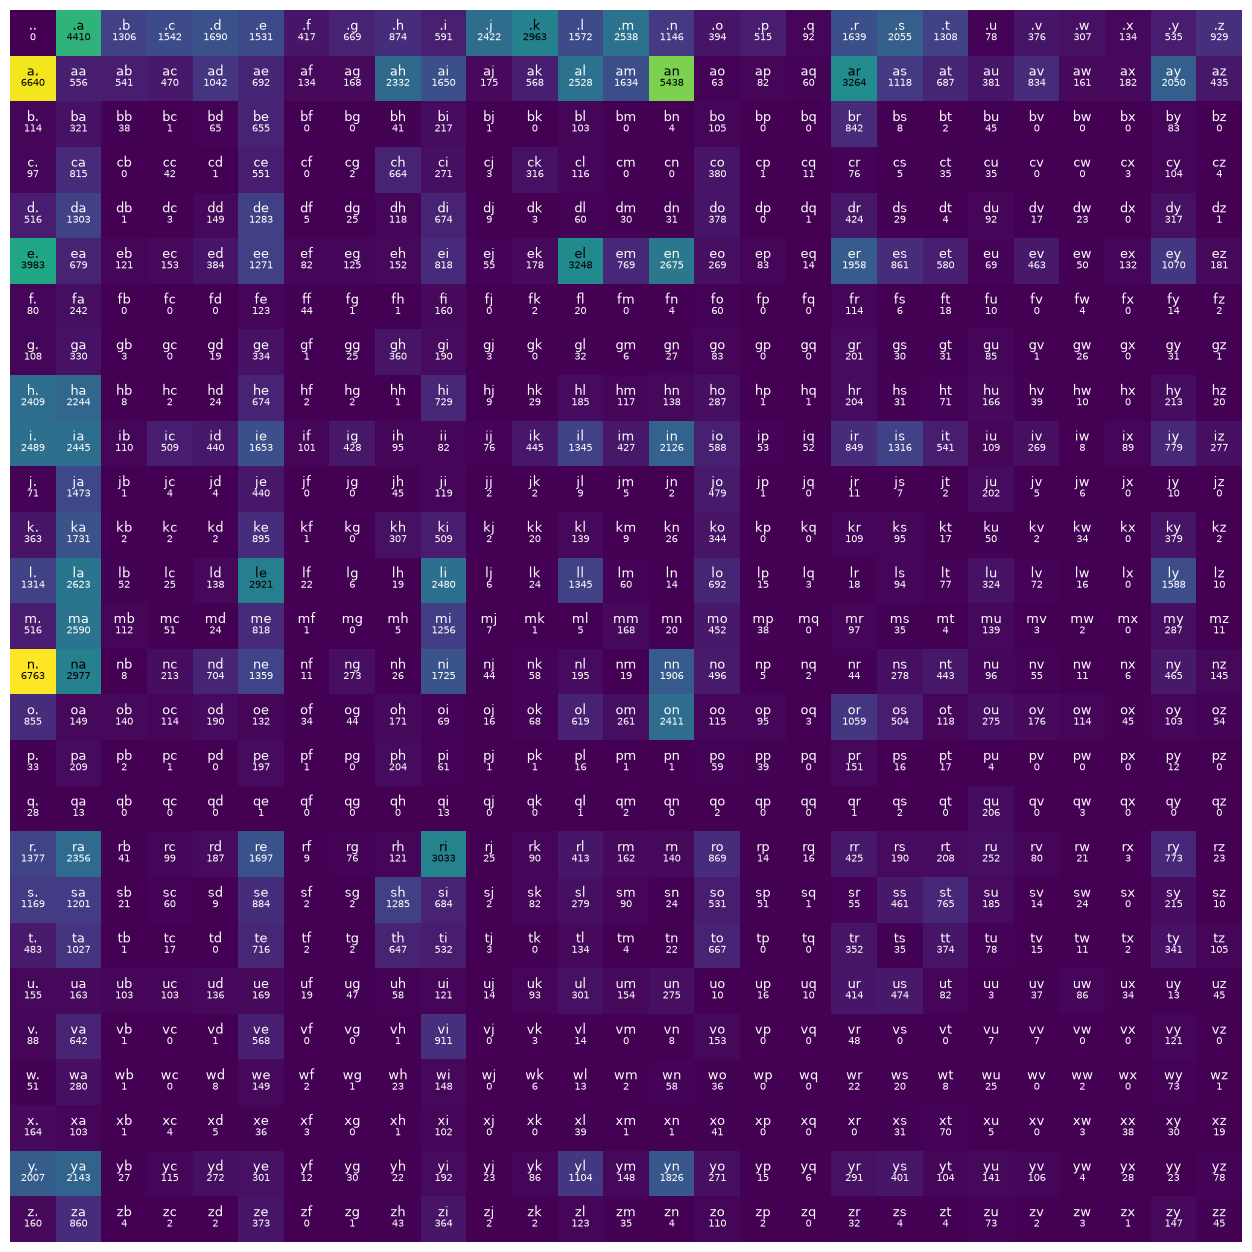

In [86]:
plt.figure(figsize=(16, 16))

N_cpu = N.cpu()
plt.imshow(N_cpu, cmap='viridis')

# Find the maximum count to normalize brightness threshold
max_val = N_cpu.max().item()

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        val = N_cpu[i, j].item()
        
        # Switch to black text on bright cells (top ~40% of colormap scale)
        color = 'black' if val > (max_val * 0.4) else 'white'

        plt.text(j, i, chstr, ha="center", va="bottom", color=color, fontsize=9)
        plt.text(j, i, str(val), ha="center", va="top", color=color, fontsize=7)

plt.axis('off')
plt.show()

In [87]:
P = (N+1).float()
P /= P.sum(axis=1, keepdim=True)

In [114]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(P[0].cpu(), num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [120]:
g = torch.Generator().manual_seed(2147483647)

idx = 0
out = []

for _ in range(5):
    while True:
        idx = torch.multinomial(P[idx].cpu(), num_samples=1, replacement=True, generator=g).item()
        out += itos[idx]
        if idx == 0:
            print("".join(out))
            out = []
            break


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [133]:
log_likelyhood = 0
n = 0
for name in names():
    name = ['.'] + list(name) + ['.']
    for s1, s2 in zip(name, name[1:]):
        idx1, idx2 = stoi[s1], stoi[s2]
        log_likelyhood += torch.log(P[idx1, idx2])
        n +=1
nll = -log_likelyhood
nll.item()/n

2.4543562565199477

In [48]:
xs, ys = [], []
for name in names():
    name = ['.'] + list(name) + ['.']
    for s1, s2 in zip(name, name[1:]):
        idx1, idx2 = stoi[s1], stoi[s2]
        xs += [idx1]
        ys += [idx2]
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [49]:
xinc = F.one_hot(xs, num_classes=27).float()
nelements = xs.nelement()

In [50]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator(device='mps').manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [53]:
for _ in range(100):
    logits = xinc@W #log-counts
    counts = logits.exp()
    probs  =  counts/counts.sum(axis=1, keepdim=True)
    nll = -probs[torch.arange(nelements), ys].log().mean()
    loss = nll+0.01*(W**2).mean()
    W.grad = None
    loss.backward()
    W.data += -10*W.grad
    print(loss.item())

2.52420711517334
2.5239052772521973
2.523606538772583
2.5233101844787598
2.523017406463623
2.5227277278900146
2.5224409103393555
2.5221574306488037
2.5218758583068848
2.5215978622436523
2.521322727203369
2.521049737930298
2.520779609680176
2.520512342453003
2.5202476978302
2.5199854373931885
2.519726276397705
2.5194690227508545
2.519214630126953
2.5189626216888428
2.5187132358551025
2.518465995788574
2.518220901489258
2.5179784297943115
2.5177383422851562
2.517500638961792
2.5172646045684814
2.51703143119812
2.5168004035949707
2.5165717601776123
2.5163447856903076
2.516119956970215
2.515897274017334
2.515676975250244
2.515458345413208
2.515242338180542
2.5150275230407715
2.514815330505371
2.5146045684814453
2.5143959522247314
2.5141892433166504
2.513984441757202
2.5137815475463867
2.513580083847046
2.513380765914917
2.513183355331421
2.5129876136779785
2.512794017791748
2.512601375579834
2.512410879135132
2.5122218132019043
2.5120346546173096
2.5118489265441895
2.511665105819702
2.5114

In [58]:
loss.item()

2.504685878753662

In [76]:
for _ in range(5):
    idx=0
    out = []
    while True:
        xinc = F.one_hot(torch.tensor([idx]), num_classes=27).float()
        logits = xinc@W
        counts = logits.exp()
        probs = counts/counts.sum(axis=1, keepdim=True)
        idx = torch.multinomial(probs, num_samples=1, replacement=True).item()
        if idx == 0: break;
        out.append(itos[idx])

    print(''.join(out))

cmazlith
rassensyal
ngphi
mamax
sheldrekda
